# Dataset Description

The dataset has large number of Wikipedia comments which have been labeled as toxic behavior by human ratings. The types of toxicity are:

- toxic
- severe_toxic
- obscene
- threat
- insult
- identity_hate

## Importing important Modules

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [45]:
df= pd.read_csv("train.csv")
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [47]:
len(df)

159571

## EDA

In [48]:
# Checking for null values
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [49]:
# This grabs the names (index) and the totals (values)
x = df.iloc[:, 2:].sum()
x

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [50]:
# Calculate the sum for each row once
rowsums = df.iloc[:, 2:].sum(axis=1)

In [51]:


# Simple loop to count comments with no labels
no_label_count = 0
for val in rowsums:
    if val == 0:
        no_label_count += 1

# Print the final summary
print(f"Total Comments: {len(df)}")
print(f"No Labels:      {no_label_count}")
print(f"Total Labels:   {rowsums.sum()}")

Total Comments: 159571
No Labels:      143346
Total Labels:   35098


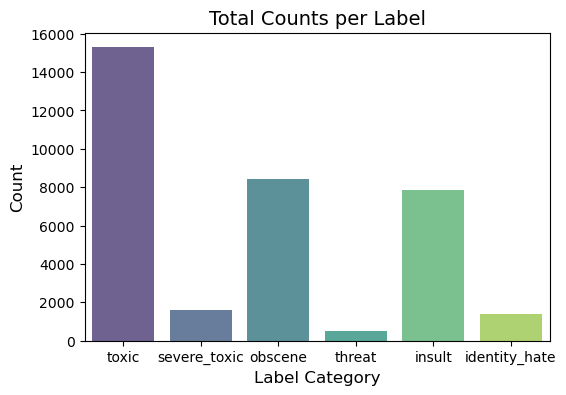

In [52]:
plt.figure(figsize=(6, 4))

# 3. Create the barplot
# Added 'hue=x.index' and 'legend=False' to satisfy modern Seaborn requirements
ax = sns.barplot(
    x=x.index, 
    y=x.values, 
    alpha=0.8, 
    palette='viridis', # 'viridis' is a clean, built-in color scale
    hue=x.index,
    legend=False
)

# 4. Add labels and title
plt.title('Total Counts per Label', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Label Category', fontsize=12)
plt.show()

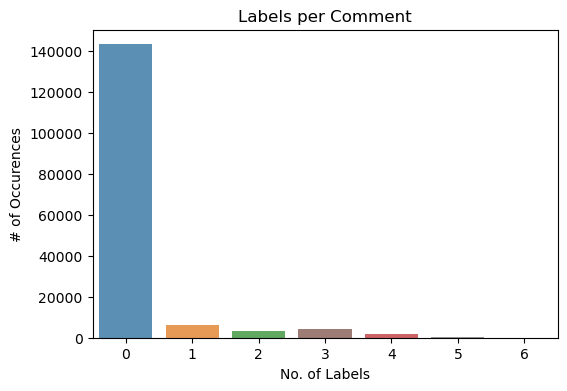

In [53]:
plt.figure(figsize=(6, 4))
sns.countplot(x=rowsums.values, alpha=0.8, palette=['tab:blue', 'tab:orange', 'tab:green', 'tab:brown', 'tab:red', 'tab:grey'])
plt.title('Labels per Comment')
plt.ylabel('# of Occurences')
plt.xlabel('No. of Labels')

plt.show()

## Data Preprocessing

In [54]:
df = df.drop('id', axis=1)
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


#### Removing stopwards

In [55]:
import nltk
from nltk.corpus import stopwords

# remove stopwords
stopwords = set(stopwords.words('english'))

def remove_stopwords(txt):
    no_stopword_text = [w for w in txt.split() if not w in stopwords]
    return " ".join(no_stopword_text)
#function call
df['comment_text'] = df['comment_text'].apply(lambda x: remove_stopwords(x))

In [56]:
df.head(2)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation Why edits made username Hardcore M...,0,0,0,0,0,0
1,D'aww! He matches background colour I'm seemin...,0,0,0,0,0,0


#### Cleaning text

In [57]:
# Import required libraries
import re
import string
from bs4 import BeautifulSoup

# Install emoji library if not already installed
# Run this in a separate cell: !pip install emoji
import emoji

def clean_txt(txt):
    # --- Part 1: Validation and Normalization ---
    if not isinstance(txt, str):                # Check if the input is actually a string
        return " "                              # If it's a number or NaN, return an empty space
    
    txt = txt.lower()                           # Convert all text to lowercase for consistency

    # --- Part 2: Fixing Contractions (Must happen before removing punctuation) ---
    txt = re.sub(r"what's", "what is ", txt)    # Change what's to what is
    txt = re.sub(r"\'ve", " have ", txt)        # Change 've to have (e.g., I've -> I have)
    txt = re.sub(r"can't", "can not ", txt)     # Change can't to can not
    txt = re.sub(r"n't", " not ", txt)          # Change n't to not (e.g., don't -> do not)
    txt = re.sub(r"i'm", "i am ", txt)          # Change i'm to i am
    txt = re.sub(r"\'re", " are ", txt)         # Change 're to are
    txt = re.sub(r"\'d", " would ", txt)        # Change 'd to would
    txt = re.sub(r"\'ll", " will ", txt)        # Change 'll to will

    # --- Part 3: Removing Noise ---
    txt = re.sub(r'http\S+|www\S+', '', txt)    # Remove website links and URLs
    txt = emoji.replace_emoji(txt, replace=" ") # Find emojis and replace them with a space
    txt = BeautifulSoup(txt, 'html.parser').get_text() # Strip out HTML tags like <div> or <br>
    txt = txt.translate(str.maketrans('', '', string.punctuation)) # Delete all remaining punctuation
    txt = re.sub(r'\d+', '', txt)               # Remove all numbers/digits

    # --- Part 4: Final Spacing ---
    words = txt.split()                         # Split text into a list of words (removes extra spaces)
    txt = " ".join(words)                       # Join words back together with a single space
    
    return txt.strip()                          # Remove any leading or trailing whitespace

# Function call
df['comment_text'] = df['comment_text'].apply(lambda x: clean_txt(x))

ModuleNotFoundError: No module named 'emoji'

In [ ]:
import re                                       # Import Regular Expressions for pattern matching
import string                                   # Import String module for punctuation lists
import emoji                                    # Import Emoji to handle icons/emoticons
from bs4 import BeautifulSoup                   # Import BeautifulSoup to clean HTML tags

def clean_txt(txt):
    # --- Part 1: Validation and Normalization ---
    if not isinstance(txt, str):                # Check if the input is actually a string
        return " "                              # If it's a number or NaN, return an empty space
    
    txt = txt.lower()                           # Convert all text to lowercase for consistency

    # --- Part 2: Fixing Contractions (Must happen before removing punctuation) ---
    txt = re.sub(r"what's", "what is ", txt)    # Change what's to what is
    txt = re.sub(r"\'ve", " have ", txt)        # Change 've to have (e.g., I've -> I have)
    txt = re.sub(r"can't", "can not ", txt)     # Change can't to can not
    txt = re.sub(r"n't", " not ", txt)          # Change n't to not (e.g., don't -> do not)
    txt = re.sub(r"i'm", "i am ", txt)          # Change i'm to i am
    txt = re.sub(r"\'re", " are ", txt)         # Change 're to are
    txt = re.sub(r"\'d", " would ", txt)        # Change 'd to would
    txt = re.sub(r"\'ll", " will ", txt)        # Change 'll to will

    # --- Part 3: Removing Noise ---
    txt = re.sub(r'http\S+|www\S+', '', txt)    # Remove website links and URLs
    txt = emoji.replace_emoji(txt, replace=" ") # Find emojis and replace them with a space
    txt = BeautifulSoup(txt, 'html.parser').get_text() # Strip out HTML tags like <div> or <br>
    txt = txt.translate(str.maketrans('', '', string.punctuation)) # Delete all remaining punctuation
    txt = re.sub(r'\d+', '', txt)               # Remove all numbers/digits

    # --- Part 4: Final Spacing ---
    words = txt.split()                         # Split text into a list of words (removes extra spaces)
    txt = " ".join(words)                       # Join words back together with a single space
    
    return txt.strip()                          # Remove any leading or trailing whitespace

#function call
df['comment_text'] = df['comment_text'].apply(lambda x: clean_txt(x))

#### Word Pruning.

In [ ]:
from nltk.stem.snowball import SnowballStemmer
# Choose the tool
stemmer = SnowballStemmer('english')

def stemming(sentence):
    # Create an empty bucket for our trimmed words
    stemmed_sentence = "" 
    
    # Take the sentence and chop it into a list of words
    for word in sentence.split():
        
        # Trim the current word to its root
        # Example: "Toxic" stays "toxic", but "Toxicity" becomes "toxic"
        stemmed_word = stemmer.stem(word)
        
        # Throw the trimmed word into our bucket with a space
        stemmed_sentence += stemmed_word + " "
        
    # Remove the very last space and give back the bucket
    return stemmed_sentence.strip()

# function call
df['comment_text'] = df['comment_text'].apply(lambda x: stemming(x))

#### Spliting the dataset

In [ ]:
# split input and output variables
X = df['comment_text']
y = df.drop("comment_text", axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
# split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, classification_report

labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

#### Function Building

In [ ]:
def evaluate_model(pipeline, X_train, X_test, y_train, y_test): #Simple text classification pipeline evaluator
    
    # Train the model
    print("Training model...")
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    predictions = pipeline.predict(X_test)
    probability_predictions = pipeline.predict_proba(X_test)
    
    # Show results
    print(f"ROC-AUC Score: {roc_auc_score(y_test, probability_predictions, average='weighted'):.3f}")
    print(f"Accuracy: {accuracy_score(y_test, predictions):.3f}")
    print("\nDetailed Performance Report:")
    print(classification_report(y_test, predictions))

#### Building different pipelines

In [ ]:
# Naive bayes pipeline
naive_bayes_pipeline = Pipeline([
    ('text_to_numbers', TfidfVectorizer(stop_words='english')),  # Convert text to numbers
    ('classifier', OneVsRestClassifier(MultinomialNB()))          # Train one model per label
])

# Logistic regression pipeline
logistic_pipeline = Pipeline([
    ('text_to_numbers', TfidfVectorizer(stop_words='english')),
    ('classifier', OneVsRestClassifier(LogisticRegression()))
])

#### Run evaluation (assuming X_train, X_test, y_train, y_test are already defined)

In [ ]:

print("=== Naive Bayes Results ===")
evaluate_model(naive_bayes_pipeline, X_train, X_test, y_train, y_test)

print("\n=== Logistic Regression Results ===")
evaluate_model(logistic_pipeline, X_train, X_test, y_train, y_test)

## Test Prediction

### Take a sample from test set (for comparison)

In [ ]:
sentence = X_test.iloc[4]  # First test example
true_labels = y_test.iloc[0]  # Actual labels for that example
prediction = logistic_pipeline.predict([sentence])[0]

# Display results
print(f"Sentence: {sentence}\n")

# Display results nicely
for label, predicted, actual in zip(labels, prediction, true_labels):
    print(f"{label:15} Predicted: {predicted}  Actual: {actual}")

### WORKFLOW 2: Function-Based Prediction

In [ ]:

def predict_sentence(model, sentence, labels):
 
    # Model expects list of strings, even if just one
    prediction = model.predict([sentence])[0]
    
    # Show results
    print(f"Input: '{sentence}'")   
    print("=" * 50)
    print("Predicted labels:")
    for label, pred in zip(labels, prediction):
        if pred == 1:
            print(f"  ✓ {label}")
    
    return prediction

# Test workflow 2 with same sentence
prediction_function = predict_sentence(logistic_pipeline, "I will kill you!", labels)

### Pick a random test example to see if model matches

In [ ]:
import random
idx = random.randint(0, len(X_test))
test_sentence = X_test.iloc[idx]
true_labels = y_test.iloc[idx]
predicted = logistic_pipeline.predict([test_sentence])[0]

print(f"Test sentence: |> {test_sentence} <|\n")
print(f"{'Label':15} {'True':6} {'Predicted':6} {'Match?'}")
print("-" * 40)
for label, true, pred in zip(labels, true_labels, predicted):
    match = "✓" if true == pred else "✗"
    print(f"{label:15} {true:6} {pred:6} {match}")